# SVM — DNA Sınıflandırma Analizi

**Veri:** synthetic_dna_dataset.csv (3.000 DNA örneği, 13 sütun)
**Hedef:** `Disease_Risk` (Low / Medium / High)

Üç kernel karşılaştırılıyor, GridSearchCV ile optimizasyon yapılıyor. Bölüm 3'te referans seviyesi modellerden önce belirleniyor; Bölüm 7'de sonuçların kaynağı teşhis ediliyor.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import (train_test_split, GridSearchCV, StratifiedKFold,
                                     cross_val_score, permutation_test_score)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110

## 1. Veri Setini Kesfetme

In [2]:
df = pd.read_csv('synthetic_dna_dataset.csv')

print('=' * 70)
print('VERI SETI BOYUTU')
print('=' * 70)
print(f'Satir sayisi: {df.shape[0]}')
print(f'Sutun sayisi: {df.shape[1]}')
print()

print('=' * 70)
print('SUTUNLAR VE VERI TIPLERI')
print('=' * 70)
for col in df.columns:
    print(f"{'%-25s' % col} | dtype: {str(df[col].dtype):<15} | Benzersiz: {df[col].nunique()}")

VERI SETI BOYUTU
Satir sayisi: 3000
Sutun sayisi: 13

SUTUNLAR VE VERI TIPLERI
Sample_ID                 | dtype: object          | Benzersiz: 3000
Sequence                  | dtype: object          | Benzersiz: 3000
GC_Content                | dtype: float64         | Benzersiz: 33
AT_Content                | dtype: float64         | Benzersiz: 33
Sequence_Length           | dtype: int64           | Benzersiz: 1
Num_A                     | dtype: int64           | Benzersiz: 30
Num_T                     | dtype: int64           | Benzersiz: 32
Num_C                     | dtype: int64           | Benzersiz: 32
Num_G                     | dtype: int64           | Benzersiz: 30
kmer_3_freq               | dtype: float64         | Benzersiz: 872
Mutation_Flag             | dtype: int64           | Benzersiz: 2
Class_Label               | dtype: object          | Benzersiz: 4
Disease_Risk              | dtype: object          | Benzersiz: 3


In [3]:
print('=' * 70)
print('DEGISKEN ISIMLERI VE ACIKLAMALARI')
print('=' * 70)
variable_info = {
    'Sample_ID': 'Her DNA ornegi icin benzersiz kimlik numarasi',
    'Sequence': 'DNA dizisi (A, T, C ve G bazlarindan olusur)',
    'GC_Content': 'Guanin (G) ve Sitozin (C) bazlarinin yuzdesi',
    'AT_Content': 'Adenin (A) ve Timin (T) bazlarinin yuzdesi',
    'Sequence_Length': 'DNA dizisinin toplam uzunlugu',
    'Num_A': 'Adenin (A) bazlarinin sayisi',
    'Num_T': 'Timin (T) bazlarinin sayisi',
    'Num_C': 'Sitozin (C) bazlarinin sayisi',
    'Num_G': 'Guanin (G) bazlarinin sayisi',
    'kmer_3_freq': 'Ortalama 3-mer (uc bazli dizilim) frekans skoru',
    'Mutation_Flag': 'Mutasyon varligini gosteren ikili degisken (0 = Yok, 1 = Var)',
    'Class_Label': 'DNA orneginin sinifi (Human, Bacteria, Virus, Plant)',
    'Disease_Risk': 'Ornegin hastalik risk seviyesi (HEDEF DEGISKEN)'
}
for var, desc in variable_info.items():
    print(f"{'%-22s' % var} | {desc}")

print()
print('=' * 70)
print('HEDEF DEGISKEN: Disease_Risk (Low / Medium / High)')
print('=' * 70)
print(f'Eksik deger sayisi : {df.isnull().sum().sum()}')
print(f'Tekrar eden satir  : {df.duplicated().sum()}')

DEGISKEN ISIMLERI VE ACIKLAMALARI
Sample_ID              | Her DNA ornegi icin benzersiz kimlik numarasi
Sequence               | DNA dizisi (A, T, C ve G bazlarindan olusur)
GC_Content             | Guanin (G) ve Sitozin (C) bazlarinin yuzdesi
AT_Content             | Adenin (A) ve Timin (T) bazlarinin yuzdesi
Sequence_Length        | DNA dizisinin toplam uzunlugu
Num_A                  | Adenin (A) bazlarinin sayisi
Num_T                  | Timin (T) bazlarinin sayisi
Num_C                  | Sitozin (C) bazlarinin sayisi
Num_G                  | Guanin (G) bazlarinin sayisi
kmer_3_freq            | Ortalama 3-mer (uc bazli dizilim) frekans skoru
Mutation_Flag          | Mutasyon varligini gosteren ikili degisken (0 = Yok, 1 = Var)
Class_Label            | DNA orneginin sinifi (Human, Bacteria, Virus, Plant)
Disease_Risk           | Ornegin hastalik risk seviyesi (HEDEF DEGISKEN)

HEDEF DEGISKEN: Disease_Risk (Low / Medium / High)
Eksik deger sayisi : 0
Tekrar eden satir  : 0


In [4]:
print('=' * 70)
print('KATEGORIK DEGISKENLERIN DAGILIMI')
print('=' * 70)
cat_columns = ['Class_Label', 'Mutation_Flag', 'Disease_Risk']
for col in cat_columns:
    print(f'\n{"-" * 50}')
    print(f'{col.upper()}')
    print(f'{"-" * 50}')
    for val, cnt in df[col].value_counts().items():
        print(f"  {'%-25s' % str(val)} : {cnt:5d} ({cnt/len(df)*100:5.2f}%)")

KATEGORIK DEGISKENLERIN DAGILIMI

--------------------------------------------------
CLASS_LABEL
--------------------------------------------------
  Bacteria                  :   761 (25.37%)
  Human                     :   749 (24.97%)
  Plant                     :   747 (24.90%)
  Virus                     :   743 (24.77%)

--------------------------------------------------
MUTATION_FLAG
--------------------------------------------------
  0                         :  1510 (50.33%)
  1                         :  1490 (49.67%)

--------------------------------------------------
DISEASE_RISK
--------------------------------------------------
  High                      :  1046 (34.87%)
  Low                       :   978 (32.60%)
  Medium                    :   976 (32.53%)


In [5]:
print('=' * 70)
print('SAYISAL DEGISKENLERIN ISTATISTIKLERI')
print('=' * 70)
num_cols = ['GC_Content', 'AT_Content', 'Sequence_Length', 'Num_A', 'Num_T', 'Num_C', 'Num_G', 'kmer_3_freq']
print(df[num_cols].describe().to_string())

SAYISAL DEGISKENLERIN ISTATISTIKLERI
        GC_Content   AT_Content  Sequence_Length        Num_A        Num_T        Num_C        Num_G  kmer_3_freq
count  3000.000000  3000.000000           3000.0  3000.000000  3000.000000  3000.000000  3000.000000  3000.000000
mean     50.120000    49.880000            100.0    24.950667    24.929333    25.004000    25.116000     0.547738
std       5.062688     5.062688              0.0     4.317458     4.317702     4.349056     4.329603     0.258521
min      34.000000    34.000000            100.0    11.000000     9.000000    10.000000    12.000000     0.100000
25%      47.000000    47.000000            100.0    22.000000    22.000000    22.000000    22.000000     0.330000
50%      50.000000    50.000000            100.0    25.000000    25.000000    25.000000    25.000000     0.543000
75%      53.000000    53.000000            100.0    28.000000    28.000000    28.000000    28.000000     0.772250
max      66.000000    66.000000            100.0   

### 1.1 Ozellik Yapisi Kontrolu

Model kurmadan once ozelliklerin birbiriyle iliskisini kontrol etmek gerekir. Yukaridaki
"Benzersiz" sutununda dikkat cekici bir deger var: `Sequence_Length` icin **1**.

Asagida uc yapisal sorunu test ediyoruz.

In [6]:
print('=' * 70)
print('YAPISAL KONTROLLER')
print('=' * 70)

# 1. Sabit sutun
print(f'1. Sequence_Length benzersiz deger sayisi: {df["Sequence_Length"].nunique()}')
print(f'   Tek deger: {df["Sequence_Length"].unique()}')
print('   -> SABIT SUTUN. Varyansi sifir, hicbir bilgi tasimaz. Cikarilmali.\n')

# 2. Tamamlayici sutunlar
print(f'2. GC_Content + AT_Content her satirda 100 mu? {((df.GC_Content + df.AT_Content) == 100).all()}')
print('   -> AT_Content = 100 - GC_Content. Ikisi ayni bilgiyi tasiyor, biri yeterli.\n')

# 3. Turetilmis sutun
print(f'3. GC_Content = Num_C + Num_G esitligi saglaniyor mu? '
      f'{(df.GC_Content == (df.Num_C + df.Num_G)).mean() * 100:.1f}% satirda')
print(f'   Num_A + Num_T + Num_C + Num_G toplami: {df[["Num_A","Num_T","Num_C","Num_G"]].sum(axis=1).unique()}')
print('   -> Dizi uzunlugu 100 oldugu icin baz sayilari dogrudan yuzde demek.')
print('      GC_Content bu sayilardan hesaplanan turetilmis bir sutun.')
print()
print('SONUC: Sequence_Length ve AT_Content modelden cikarilacak.')
print('       GC_Content tutulacak (Num_C, Num_G ile birlikte tam bagimlilik yaratsa da')
print('       SVM icin dogrusal bagimlilik regresyondaki kadar yikici degildir).')

YAPISAL KONTROLLER
1. Sequence_Length benzersiz deger sayisi: 1
   Tek deger: [100]
   -> SABIT SUTUN. Varyansi sifir, hicbir bilgi tasimaz. Cikarilmali.

2. GC_Content + AT_Content her satirda 100 mu? True
   -> AT_Content = 100 - GC_Content. Ikisi ayni bilgiyi tasiyor, biri yeterli.

3. GC_Content = Num_C + Num_G esitligi saglaniyor mu? 100.0% satirda
   Num_A + Num_T + Num_C + Num_G toplami: [100]
   -> Dizi uzunlugu 100 oldugu icin baz sayilari dogrudan yuzde demek.
      GC_Content bu sayilardan hesaplanan turetilmis bir sutun.

SONUC: Sequence_Length ve AT_Content modelden cikarilacak.
       GC_Content tutulacak (Num_C, Num_G ile birlikte tam bagimlilik yaratsa da
       SVM icin dogrusal bagimlilik regresyondaki kadar yikici degildir).


In [7]:
# Hedef degiskene gore ozellik ortalamalari
print('=' * 70)
print('OZELLIK ORTALAMALARININ SINIFLARA GORE DAGILIMI')
print('=' * 70)
ozet = df.groupby('Disease_Risk')[['GC_Content', 'Num_A', 'Num_T', 'Num_C', 'Num_G', 'kmer_3_freq']].mean()
print(ozet.round(3).to_string())
print()
print('Siniflar arasi en buyuk fark:')
for c in ['GC_Content', 'Num_A', 'Num_T', 'Num_C', 'Num_G', 'kmer_3_freq']:
    fark = ozet[c].max() - ozet[c].min()
    std = df[c].std()
    print(f'  {c:<14}: {fark:>6.3f}  (degiskenin std sapmasi: {std:.3f} -> farkin std\'ye orani: {fark/std:.3f})')
print()
print('YORUM: Siniflar arasi ortalama farklari, degiskenlerin kendi standart')
print('       sapmalarinin yanindan bile gecmiyor. Bu, siniflarin ozellik')
print('       uzayinda ust uste bindigine dair ilk ciddi isaret.')

OZELLIK ORTALAMALARININ SINIFLARA GORE DAGILIMI
              GC_Content   Num_A   Num_T   Num_C   Num_G  kmer_3_freq
Disease_Risk                                                         
High              50.360  24.798  24.841  25.090  25.271        0.541
Low               49.771  25.212  25.017  24.765  25.006        0.545
Medium            50.212  24.852  24.935  25.152  25.060        0.558

Siniflar arasi en buyuk fark:
  GC_Content    :  0.589  (degiskenin std sapmasi: 5.063 -> farkin std'ye orani: 0.116)
  Num_A         :  0.413  (degiskenin std sapmasi: 4.317 -> farkin std'ye orani: 0.096)
  Num_T         :  0.176  (degiskenin std sapmasi: 4.318 -> farkin std'ye orani: 0.041)
  Num_C         :  0.387  (degiskenin std sapmasi: 4.349 -> farkin std'ye orani: 0.089)
  Num_G         :  0.264  (degiskenin std sapmasi: 4.330 -> farkin std'ye orani: 0.061)
  kmer_3_freq   :  0.016  (degiskenin std sapmasi: 0.259 -> farkin std'ye orani: 0.063)

YORUM: Siniflar arasi ortalama farklari, d

## 2. Veri On Isleme (Preprocessing)

SVM mesafe tabanli bir algoritma oldugu icin:
1. **Kategorik degiskenler** sayisala cevrilmeli (LabelEncoder)
2. **Sayisal degiskenler** olceklendirilmeli (StandardScaler)
3. **Egitim/test** ayrimi yapilmali

Bolum 1.1'deki bulgular geregi `Sequence_Length` (sabit) ve `AT_Content` (tamamlayici)
ozellik listesine alinmiyor. `Sample_ID` ve `Sequence` de dogrudan kullanilamaz;
`Sequence` sutunundan ozellik cikarimi Bolum 7.3'te ayrica denenecek.

In [8]:
feature_cols = [
    'GC_Content',
    'Num_A',
    'Num_T',
    'Num_C',
    'Num_G',
    'kmer_3_freq',
    'Mutation_Flag',
    'Class_Label'
]

X = df[feature_cols].copy()
y = df['Disease_Risk']

print('KULLANILACAK BAGIMSIZ DEGISKENLER (X):')
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")
print(f'\nCIKARILAN SUTUNLAR:')
print(f'  Sample_ID        -> kimlik numarasi, bilgi tasimaz')
print(f'  Sequence         -> metin, dogrudan kullanilamaz (bkz. Bolum 7.3)')
print(f'  Sequence_Length  -> sabit sutun (varyans = 0)')
print(f'  AT_Content       -> GC_Content ile tam tamamlayici (100 - GC)')
print(f'\nHEDEF DEGISKEN (y): Disease_Risk')

KULLANILACAK BAGIMSIZ DEGISKENLER (X):
   1. GC_Content
   2. Num_A
   3. Num_T
   4. Num_C
   5. Num_G
   6. kmer_3_freq
   7. Mutation_Flag
   8. Class_Label

CIKARILAN SUTUNLAR:
  Sample_ID        -> kimlik numarasi, bilgi tasimaz
  Sequence         -> metin, dogrudan kullanilamaz (bkz. Bolum 7.3)
  Sequence_Length  -> sabit sutun (varyans = 0)
  AT_Content       -> GC_Content ile tam tamamlayici (100 - GC)

HEDEF DEGISKEN (y): Disease_Risk


In [9]:
cat_cols = ['Class_Label', 'Mutation_Flag']

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print('KATEGORIK DEGISKENLER SAYISALLASTIRILDI (LabelEncoder)')
print(f'\n{"Degisken":<25} {"Siniflar":<50}')
print('\u2500' * 75)
for col in cat_cols:
    classes = label_encoders[col].classes_
    class_str = ', '.join([f"{i}:{c}" for i, c in enumerate(classes)])
    print(f"{col:<25} {class_str:<50}")

le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)
print(f'\nHedef degisken (Disease_Risk) kodlama:')
for i, cls in enumerate(le_y.classes_):
    print(f"  {i} -> {cls}")

KATEGORIK DEGISKENLER SAYISALLASTIRILDI (LabelEncoder)

Degisken                  Siniflar                                          
───────────────────────────────────────────────────────────────────────────
Class_Label               0:Bacteria, 1:Human, 2:Plant, 3:Virus             
Mutation_Flag             0:0, 1:1                                          

Hedef degisken (Disease_Risk) kodlama:
  0 -> High
  1 -> Low
  2 -> Medium


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print('VERI AYRIMI (Train/Test)')
print(f'  Egitim seti  : {X_train.shape[0]} ornek (%80)')
print(f'  Test seti    : {X_test.shape[0]} ornek (%20)')
print(f'  Stratify     : Evet (sinif dagilimi korundu)')

VERI AYRIMI (Train/Test)
  Egitim seti  : 2400 ornek (%80)
  Test seti    : 600 ornek (%20)
  Stratify     : Evet (sinif dagilimi korundu)


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('VERI OLCEKLENDIRILDI (StandardScaler)')
print(f'  Ortalama (her sutun icin): 0')
print(f'  Standart sapma (her sutun icin): 1')
print(f'  X_train_scaled boyutu: {X_train_scaled.shape}')
print(f'  X_test_scaled boyutu : {X_test_scaled.shape}')

VERI OLCEKLENDIRILDI (StandardScaler)
  Ortalama (her sutun icin): 0
  Standart sapma (her sutun icin): 1
  X_train_scaled boyutu: (2400, 8)
  X_test_scaled boyutu : (600, 8)


## 3. Referans (Baseline) Seviyesinin Belirlenmesi

Bu bolum modelleri egitmeden ONCE calistirilmalidir. Bir dogruluk degeri tek basina anlamli degildir; kiyaslama noktasi gerekir.

| Referans | Strateji |
|---|---|
| `most_frequent` | Her zaman en kalabalik sinifi tahmin et |
| `stratified` | Sinif oranlarina gore rastgele tahmin et |

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('=' * 55)
print('REFERANS (BASELINE) SEVIYELERI')
print('=' * 55)

dummy_freq = cross_val_score(DummyClassifier(strategy='most_frequent'),
                             X, y_encoded, cv=cv, scoring='accuracy').mean()
dummy_strat = cross_val_score(DummyClassifier(strategy='stratified', random_state=42),
                              X, y_encoded, cv=cv, scoring='accuracy').mean()

print(f'  En kalabalik sinifi secme (most_frequent) : {dummy_freq:.4f}')
print(f'  Sinif oranlarina gore rastgele (stratified): {dummy_strat:.4f}')
print()
print(f'>>> HEDEF: Kuracagimiz SVM modelinin {dummy_freq:.4f} degerini ASMASI gerekiyor.')
print('>>> Bu esigin altinda kalan bir model, hicbir sey ogrenmemis demektir.')

REFERANS (BASELINE) SEVIYELERI
  En kalabalik sinifi secme (most_frequent) : 0.3487
  Sinif oranlarina gore rastgele (stratified): 0.3273

>>> HEDEF: Kuracagimiz SVM modelinin 0.3487 degerini ASMASI gerekiyor.
>>> Bu esigin altinda kalan bir model, hicbir sey ogrenmemis demektir.


## 4. SVM Modelleri

Linear, RBF ve polinom kernel ile uc model egitiliyor.

In [13]:
print('=' * 50)
print('LINEAR SVM')
print('=' * 50)
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)
y_pred_linear = svm_linear.predict(X_test_scaled)
acc_linear = accuracy_score(y_test, y_pred_linear)
print(f'Test dogrulugu: {acc_linear:.4f}')
print(f'Destek vektor sayisi: {svm_linear.n_support_.sum()}')
print('\nSiniflandirma Raporu:')
print(classification_report(y_test, y_pred_linear, target_names=le_y.classes_))

LINEAR SVM
Test dogrulugu: 0.3233
Destek vektor sayisi: 2397

Siniflandirma Raporu:
              precision    recall  f1-score   support

        High       0.34      0.52      0.42       209
         Low       0.31      0.21      0.25       196
      Medium       0.29      0.23      0.25       195

    accuracy                           0.32       600
   macro avg       0.32      0.32      0.31       600
weighted avg       0.32      0.32      0.31       600



In [14]:
print('=' * 50)
print('RBF SVM (Varsayilan)')
print('=' * 50)
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = svm_rbf.predict(X_test_scaled)
acc_rbf = accuracy_score(y_test, y_pred_rbf)
print(f'Test dogrulugu: {acc_rbf:.4f}')
print(f'Destek vektor sayisi: {svm_rbf.n_support_.sum()}')
print('\nSiniflandirma Raporu:')
print(classification_report(y_test, y_pred_rbf, target_names=le_y.classes_))

RBF SVM (Varsayilan)
Test dogrulugu: 0.3267
Destek vektor sayisi: 2377

Siniflandirma Raporu:
              precision    recall  f1-score   support

        High       0.35      0.51      0.41       209
         Low       0.30      0.23      0.26       196
      Medium       0.31      0.22      0.26       195

    accuracy                           0.33       600
   macro avg       0.32      0.32      0.31       600
weighted avg       0.32      0.33      0.31       600



In [15]:
print('=' * 50)
print('POLINOMIAL SVM (degree=3)')
print('=' * 50)
svm_poly = SVC(kernel='poly', degree=3, random_state=42)
svm_poly.fit(X_train_scaled, y_train)
y_pred_poly = svm_poly.predict(X_test_scaled)
acc_poly = accuracy_score(y_test, y_pred_poly)
print(f'Test dogrulugu: {acc_poly:.4f}')
print(f'Destek vektor sayisi: {svm_poly.n_support_.sum()}')

POLINOMIAL SVM (degree=3)
Test dogrulugu: 0.3233
Destek vektor sayisi: 2373


In [16]:
# Uc kernelin referansla karsilastirilmasi
print('=' * 60)
print('KERNEL KARSILASTIRMASI (referans cizgisiyle birlikte)')
print('=' * 60)
print(f'{"Model":<28} {"Test Dogrulugu":>15} {"Referansa Gore":>16}')
print('\u2500' * 60)
for ad, acc in [('Linear SVM', acc_linear), ('RBF SVM', acc_rbf), ('Polinomial SVM', acc_poly)]:
    fark = acc - dummy_freq
    print(f'{ad:<28} {acc:>15.4f} {fark:>+16.4f}')
print(f'{"REFERANS (most_frequent)":<28} {dummy_freq:>15.4f} {"-":>16}')

KERNEL KARSILASTIRMASI (referans cizgisiyle birlikte)
Model                         Test Dogrulugu   Referansa Gore
────────────────────────────────────────────────────────────
Linear SVM                            0.3233          -0.0253
RBF SVM                               0.3267          -0.0220
Polinomial SVM                        0.3233          -0.0253
REFERANS (most_frequent)              0.3487                -


## 5. Hiperparametre Optimizasyonu (GridSearchCV)

- C: [0.1, 1, 10, 100]
- gamma: ['scale', 'auto', 0.1, 0.01]
- kernel: ['rbf']
- 5-fold CV

In [17]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf']
}

print('ARANAN PARAMETRELER:')
for k, v in param_grid.items():
    print(f'  {k}: {v}')
print(f'\nToplam kombinasyon: {len(param_grid["C"]) * len(param_grid["gamma"])}')
print(f'Toplam model (5-fold CV ile): {len(param_grid["C"]) * len(param_grid["gamma"]) * 5}')

ARANAN PARAMETRELER:
  C: [0.1, 1, 10, 100]
  gamma: ['scale', 'auto', 0.1, 0.01]
  kernel: ['rbf']

Toplam kombinasyon: 16
Toplam model (5-fold CV ile): 80


In [18]:
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5,
                           scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print(f'\n{"=" * 50}')
print('EN IYI PARAMETRELER')
print('=' * 50)
print(f'C          : {grid_search.best_params_["C"]}')
print(f'gamma      : {grid_search.best_params_["gamma"]}')
print(f'kernel     : {grid_search.best_params_["kernel"]}')
print(f'CV skoru   : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 16 candidates, totalling 80 fits

EN IYI PARAMETRELER
C          : 0.1
gamma      : scale
kernel     : rbf
CV skoru   : 0.3525


In [19]:
# Grid uzerindeki tum kombinasyonlarin skorlari
sonuclar = pd.DataFrame(grid_search.cv_results_)[
    ['param_C', 'param_gamma', 'mean_test_score', 'std_test_score']
].sort_values('mean_test_score', ascending=False)

print('TUM PARAMETRE KOMBINASYONLARI (yuksekten dusuge):')
print(sonuclar.to_string(index=False))
print()
print(f'En iyi ile en kotu arasindaki fark: '
      f'{sonuclar["mean_test_score"].max() - sonuclar["mean_test_score"].min():.4f}')
print()
print('YORUM: 16 farkli parametre kombinasyonunun tamami birbirine cok yakin.')
print('       Hiperparametre secimi sonucu neredeyse hic degistirmiyor. Bu, modelin')
print('       parametrelerinden degil VERIDEN kaynaklanan bir sinira carptigini gosterir.')

TUM PARAMETRE KOMBINASYONLARI (yuksekten dusuge):
 param_C param_gamma  mean_test_score  std_test_score
     0.1       scale         0.352500        0.005496
     0.1        auto         0.352500        0.005496
     1.0        0.01         0.352083        0.009772
    10.0        0.01         0.351667        0.009446
     0.1         0.1         0.350833        0.006264
     0.1        0.01         0.348750        0.001021
   100.0        0.01         0.347500        0.019021
     1.0         0.1         0.337500        0.008437
     1.0        auto         0.332917        0.010737
   100.0       scale         0.332917        0.020000
     1.0       scale         0.332500        0.010257
   100.0        auto         0.332500        0.020480
   100.0         0.1         0.327500        0.019957
    10.0        auto         0.320417        0.023878
    10.0       scale         0.319583        0.023885
    10.0         0.1         0.318333        0.029357

En iyi ile en kotu arasindaki f

## 6. En Iyi Model - Detayli Degerlendirme

In [20]:
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test_scaled)
acc_best = accuracy_score(y_test, y_pred_best)

print('=' * 50)
print('EN IYI MODEL SONUCLARI')
print('=' * 50)
print(f'Test dogrulugu: {acc_best:.4f}')
print(f'Cross-validation skoru: {grid_search.best_score_:.4f}')
print(f'Referans seviyesi: {dummy_freq:.4f}')
print(f'Referansa gore kazanc: {acc_best - dummy_freq:+.4f}')
print(f'\nSiniflandirma Raporu:')
print(classification_report(y_test, y_pred_best, target_names=le_y.classes_))

EN IYI MODEL SONUCLARI
Test dogrulugu: 0.3467
Cross-validation skoru: 0.3525
Referans seviyesi: 0.3487
Referansa gore kazanc: -0.0020

Siniflandirma Raporu:
              precision    recall  f1-score   support

        High       0.35      0.93      0.51       209
         Low       0.33      0.07      0.11       196
      Medium       0.00      0.00      0.00       195

    accuracy                           0.35       600
   macro avg       0.23      0.33      0.21       600
weighted avg       0.23      0.35      0.21       600



In [21]:
print('=' * 50)
print('KARISIKLIK MATRISI (Confusion Matrix)')
print('=' * 50)
cm = confusion_matrix(y_test, y_pred_best)
print('Satirlar: GERCEK deger | Sutunlar: TAHMIN edilen deger')
print()
header = ' ' * 22 + ' '.join(f'{c:>18}' for c in le_y.classes_)
print(header)
print('\u2500' * len(header))
for i, row in enumerate(cm):
    print(f"{le_y.classes_[i]:<22}" + ' '.join(f'{val:>18}' for val in row))
print()
print('Yorum: Kosegen (diagonal) ne kadar yuksekse model o kadar basarili.')
print()

# Tahmin dagilimi analizi
tahmin_dagilimi = pd.Series(y_pred_best).value_counts().sort_index()
print('MODELIN TAHMIN DAGILIMI:')
for i, cls in enumerate(le_y.classes_):
    adet = tahmin_dagilimi.get(i, 0)
    gercek_adet = (y_test == i).sum()
    print(f'  {cls:<10}: {adet:>4} tahmin edildi  (gercekte {gercek_adet} adet var)')
print()
print('Model sutunlarin cogunu tek bir sinifa yigiyorsa, siniflari ayirt etmeyi')
print('ogrenmemis, sadece en kalabalik sinifa cokmus demektir.')

KARISIKLIK MATRISI (Confusion Matrix)
Satirlar: GERCEK deger | Sutunlar: TAHMIN edilen deger

                                    High                Low             Medium
──────────────────────────────────────────────────────────────────────────────
High                                 195                 14                  0
Low                                  183                 13                  0
Medium                               183                 12                  0

Yorum: Kosegen (diagonal) ne kadar yuksekse model o kadar basarili.

MODELIN TAHMIN DAGILIMI:
  High      :  561 tahmin edildi  (gercekte 209 adet var)
  Low       :   39 tahmin edildi  (gercekte 196 adet var)
  Medium    :    0 tahmin edildi  (gercekte 195 adet var)

Model sutunlarin cogunu tek bir sinifa yigiyorsa, siniflari ayirt etmeyi
ogrenmemis, sadece en kalabalik sinifa cokmus demektir.


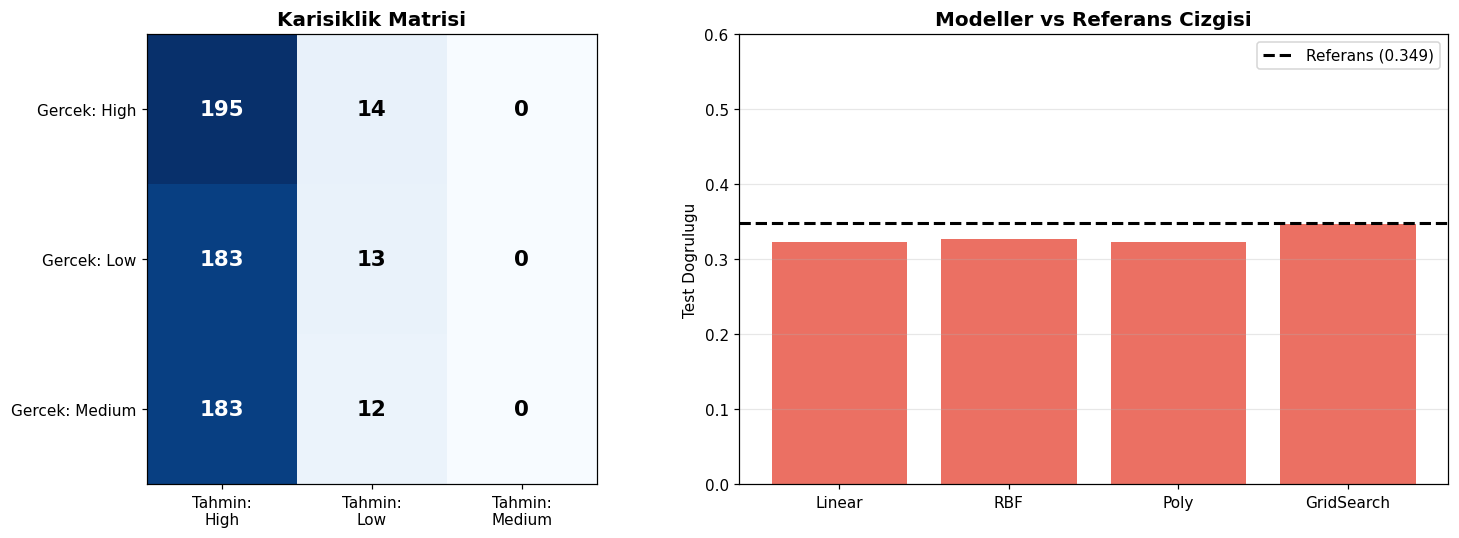

Kirmizi barlar referans cizgisinin ALTINDA kalan modelleri gosterir.


In [22]:
# Karisiklik matrisinin gorsellestirilmesi
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

im = ax[0].imshow(cm, cmap='Blues')
ax[0].set_xticks(range(len(le_y.classes_)))
ax[0].set_yticks(range(len(le_y.classes_)))
ax[0].set_xticklabels([f'Tahmin:\n{c}' for c in le_y.classes_])
ax[0].set_yticklabels([f'Gercek: {c}' for c in le_y.classes_])
for i in range(len(le_y.classes_)):
    for j in range(len(le_y.classes_)):
        ax[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=14,
                   fontweight='bold', color='white' if cm[i, j] > cm.max()/2 else 'black')
ax[0].set_title('Karisiklik Matrisi', fontsize=13, fontweight='bold')

modeller = ['Linear', 'RBF', 'Poly', 'GridSearch']
skorlar = [acc_linear, acc_rbf, acc_poly, acc_best]
renkler = ['#3498db' if s > dummy_freq else '#e74c3c' for s in skorlar]
ax[1].bar(modeller, skorlar, color=renkler, alpha=0.8)
ax[1].axhline(dummy_freq, color='black', linestyle='--', linewidth=2,
              label=f'Referans ({dummy_freq:.3f})')
ax[1].set_ylabel('Test Dogrulugu')
ax[1].set_ylim(0, 0.6)
ax[1].set_title('Modeller vs Referans Cizgisi', fontsize=13, fontweight='bold')
ax[1].legend()
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('Kirmizi barlar referans cizgisinin ALTINDA kalan modelleri gosterir.')

In [23]:
print('=' * 50)
print('DESTEK VEKTOR ANALIZI')
print('=' * 50)
print(f'Toplam destek vektor sayisi  : {best_svm.n_support_.sum()}')
print(f'Toplam egitim ornegi         : {len(X_train_scaled)}')
oran = best_svm.n_support_.sum() / len(X_train_scaled) * 100
print(f'Destek vektor orani          : {oran:.1f}%')
print()
print('Her sinif icin destek vektor sayisi:')
for i, cls in enumerate(le_y.classes_):
    print(f'  {cls:<20} : {best_svm.n_support_[i]} vektor')
print()
if oran > 90:
    print(f'>>> Oran %{oran:.1f}. Model, egitim setindeki neredeyse her noktayi')
    print('    destek vektoru olarak isaretlemis. Ayrilabilir bir yapi bulunamadi.')

DESTEK VEKTOR ANALIZI
Toplam destek vektor sayisi  : 2399
Toplam egitim ornegi         : 2400
Destek vektor orani          : 100.0%

Her sinif icin destek vektor sayisi:
  High                 : 836 vektor
  Low                  : 782 vektor
  Medium               : 781 vektor

>>> Oran %100.0. Model, egitim setindeki neredeyse her noktayi
    destek vektoru olarak isaretlemis. Ayrilabilir bir yapi bulunamadi.


In [24]:
print('=' * 50)
print('ORNEK TAHMIN (Test Setinden 10 Kayit)')
print('=' * 50)
print(f'{"No":<5} {"Tahmin":<22} {"Gercek":<22} {"Dogru?":<8}')
print('\u2500' * 55)
dogru_sayisi = 0
for i in range(10):
    tahmin = le_y.inverse_transform([best_svm.predict(X_test_scaled[i].reshape(1, -1))[0]])[0]
    gercek = le_y.inverse_transform([y_test[i]])[0]
    dogru = '\u2713' if tahmin == gercek else '\u2717'
    if tahmin == gercek:
        dogru_sayisi += 1
    print(f"{i+1:<5} {tahmin:<22} {gercek:<22} {dogru:<8}")
print('\u2500' * 55)
print(f'10 ornekte {dogru_sayisi} dogru tahmin')

ORNEK TAHMIN (Test Setinden 10 Kayit)
No    Tahmin                 Gercek                 Dogru?  
───────────────────────────────────────────────────────
1     High                   Medium                 ✗       
2     High                   Medium                 ✗       
3     High                   Low                    ✗       
4     High                   High                   ✓       
5     Low                    Medium                 ✗       
6     High                   Medium                 ✗       
7     High                   High                   ✓       
8     High                   Low                    ✗       
9     High                   Medium                 ✗       
10    High                   Low                    ✗       
───────────────────────────────────────────────────────
10 ornekte 2 dogru tahmin


## 7. Teshis: Sorun Algoritmada mi, Veride mi?

Bolum 4-6'daki sonuclar referans cizgisini asmadi. Iki olasiligi ayirt etmek icin dort test yapiliyor.

### 7.1 Permutasyon Testi

Hedef degisken rastgele karistirilirsa ozellikler ile hedef arasindaki tum gercek iliski yok olur. Modelin bu bozulmus veride aldigi skor, saf sansin olcusudur.

p < 0.05 → model gercek bir iliski yakalamis
p > 0.05 → model ile rastgele tahmin arasinda fark yok

In [25]:
print('Permutasyon testi calisiyor (50 permutasyon, birkac dakika surebilir)...')
print()

skor, permutasyon_skorlari, p_degeri = permutation_test_score(
    make_pipeline(StandardScaler(), SVC(random_state=42)),
    X, y_encoded, cv=cv, n_permutations=50, random_state=42, n_jobs=-1
)

print('=' * 55)
print('PERMUTASYON TESTI SONUCU')
print('=' * 55)
print(f'  Gercek veriyle CV skoru        : {skor:.4f}')
print(f'  Permute edilmis veri ortalamasi: {permutasyon_skorlari.mean():.4f}')
print(f'  Permute edilmis veri std sapmasi: {permutasyon_skorlari.std():.4f}')
print(f'  p-degeri                       : {p_degeri:.4f}')
print()
if p_degeri > 0.05:
    print('>>> p > 0.05: Model, hedef degiskeni rastgele karistirilmis veriden')
    print('    ISTATISTIKSEL OLARAK AYIRT EDILEMIYOR.')
    print('    Yani ozellikler ile Disease_Risk arasinda ogrenilebilir bir iliski YOK.')
else:
    print('>>> p < 0.05: Model gercek bir iliski yakalamis.')

Permutasyon testi calisiyor (50 permutasyon, birkac dakika surebilir)...

PERMUTASYON TESTI SONUCU
  Gercek veriyle CV skoru        : 0.3273
  Permute edilmis veri ortalamasi: 0.3358
  Permute edilmis veri std sapmasi: 0.0089
  p-degeri                       : 0.8431

>>> p > 0.05: Model, hedef degiskeni rastgele karistirilmis veriden
    ISTATISTIKSEL OLARAK AYIRT EDILEMIYOR.
    Yani ozellikler ile Disease_Risk arasinda ogrenilebilir bir iliski YOK.


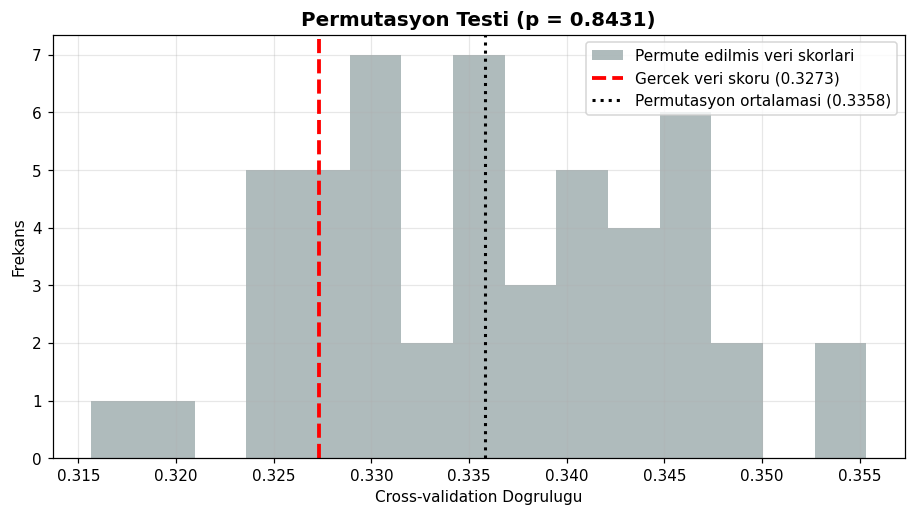

Kirmizi cizgi gri dagilimin ICINDE kaliyorsa model rastgeleden ayirt edilemiyor.


In [26]:
# Permutasyon dagiliminin gorsellestirilmesi
plt.figure(figsize=(10, 5))
plt.hist(permutasyon_skorlari, bins=15, color='#95a5a6', alpha=0.75,
         label='Permute edilmis veri skorlari')
plt.axvline(skor, color='red', linestyle='--', linewidth=2.5,
            label=f'Gercek veri skoru ({skor:.4f})')
plt.axvline(permutasyon_skorlari.mean(), color='black', linestyle=':', linewidth=2,
            label=f'Permutasyon ortalamasi ({permutasyon_skorlari.mean():.4f})')
plt.xlabel('Cross-validation Dogrulugu')
plt.ylabel('Frekans')
plt.title(f'Permutasyon Testi (p = {p_degeri:.4f})', fontweight='bold', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('Kirmizi cizgi gri dagilimin ICINDE kaliyorsa model rastgeleden ayirt edilemiyor.')

### 7.2 Alternatif Hedef Degiskenler

In [27]:
print('=' * 70)
print('FARKLI HEDEF DEGISKENLERLE SVM PERFORMANSI')
print('=' * 70)
print(f'{"Hedef":<16} {"Sinif":>6} {"Referans":>10} {"SVM CV":>10} {"Fark":>10}')
print('\u2500' * 70)

tum_ozellikler = ['GC_Content', 'Num_A', 'Num_T', 'Num_C', 'Num_G', 'kmer_3_freq',
                  'Mutation_Flag', 'Class_Label']

for hedef in ['Disease_Risk', 'Class_Label', 'Mutation_Flag']:
    kullanilacak = [c for c in tum_ozellikler if c != hedef]
    X_alt = df[kullanilacak].copy()
    for c in X_alt.columns:
        if not pd.api.types.is_numeric_dtype(X_alt[c]):
            X_alt[c] = LabelEncoder().fit_transform(X_alt[c].astype(str))
    y_alt = LabelEncoder().fit_transform(df[hedef])

    referans = pd.Series(y_alt).value_counts(normalize=True).max()
    svm_skor = cross_val_score(make_pipeline(StandardScaler(), SVC(random_state=42)),
                               X_alt, y_alt, cv=cv, scoring='accuracy').mean()
    print(f'{hedef:<16} {len(np.unique(y_alt)):>6} {referans:>10.4f} '
          f'{svm_skor:>10.4f} {svm_skor - referans:>+10.4f}')

print()
print('YORUM: Uc hedegin ucunde de SVM referans cizgisini asamiyor.')
print('       Sorun tek bir sutunda degil, veri setinin tamaminda.')

FARKLI HEDEF DEGISKENLERLE SVM PERFORMANSI
Hedef             Sinif   Referans     SVM CV       Fark
──────────────────────────────────────────────────────────────────────
Disease_Risk          3     0.3487     0.3273    -0.0213
Class_Label           4     0.2537     0.2480    -0.0057
Mutation_Flag         2     0.5033     0.5063    +0.0030

YORUM: Uc hedegin ucunde de SVM referans cizgisini asamiyor.
       Sorun tek bir sutunda degil, veri setinin tamaminda.


### 7.3 Ham DNA Dizisinden K-mer Ozellikleri

Hazir ozellik sutunlari bilgi kaybediyor olabilir. Dizilerden k-mer frekans ozellikleri cikarilip test ediliyor (k=1: 4 ozellik, k=2: 16, k=3: 64).

In [28]:
from itertools import product

def kmer_ozellikleri(diziler, k):
    # k uzunlugundaki tum alt dizilerin frekans matrisini olusturur.
    kmerler = [''.join(p) for p in product('ACGT', repeat=k)]
    indeks = {km: i for i, km in enumerate(kmerler)}
    M = np.zeros((len(diziler), len(kmerler)))
    for r, s in enumerate(diziler):
        for i in range(len(s) - k + 1):
            j = indeks.get(s[i:i+k])
            if j is not None:
                M[r, j] += 1
    return M, kmerler

diziler = df['Sequence'].values
print('=' * 70)
print('HAM DIZIDEN K-MER OZELLIKLERI ILE SVM')
print('=' * 70)
print(f'{"k":>3} {"Ozellik":>9} {"Hedef":<16} {"Referans":>10} {"SVM CV":>10} {"Fark":>9}')
print('\u2500' * 70)

for k in [1, 2, 3]:
    M, kmerler = kmer_ozellikleri(diziler, k)
    for hedef in ['Disease_Risk', 'Class_Label']:
        y_k = LabelEncoder().fit_transform(df[hedef])
        referans = pd.Series(y_k).value_counts(normalize=True).max()
        skor_k = cross_val_score(make_pipeline(StandardScaler(), SVC(random_state=42)),
                                 M, y_k, cv=cv, scoring='accuracy').mean()
        print(f'{k:>3} {len(kmerler):>9} {hedef:<16} {referans:>10.4f} '
              f'{skor_k:>10.4f} {skor_k - referans:>+9.4f}')

print()
print('YORUM: 64 boyutlu k-mer uzayinda bile sinyal yok. Diziler rastgele')
print('       uretilmis, siniflara ozgu bir baz kompozisyonu tasimiyorlar.')

HAM DIZIDEN K-MER OZELLIKLERI ILE SVM
  k   Ozellik Hedef              Referans     SVM CV      Fark
──────────────────────────────────────────────────────────────────────
  1         4 Disease_Risk         0.3487     0.3420   -0.0067
  1         4 Class_Label          0.2537     0.2300   -0.0237
  2        16 Disease_Risk         0.3487     0.3347   -0.0140
  2        16 Class_Label          0.2537     0.2487   -0.0050
  3        64 Disease_Risk         0.3487     0.3260   -0.0227
  3        64 Class_Label          0.2537     0.2430   -0.0107

YORUM: 64 boyutlu k-mer uzayinda bile sinyal yok. Diziler rastgele
       uretilmis, siniflara ozgu bir baz kompozisyonu tasimiyorlar.


### 7.4 Farkli Algoritmalarla Capraz Kontrol

Random Forest ve Lojistik Regresyon ile ayni sonuca varilip varilmadigi kontrol ediliyor.

In [29]:
print('=' * 60)
print('ALGORITMA KARSILASTIRMASI (Disease_Risk hedefi)')
print('=' * 60)
print(f'{"Algoritma":<26} {"CV Dogruluk":>13} {"Referansa Gore":>16}')
print('\u2500' * 60)

algoritmalar = {
    'SVM (RBF)': make_pipeline(StandardScaler(), SVC(random_state=42)),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Lojistik Regresyon': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    'Referans (most_frequent)': DummyClassifier(strategy='most_frequent'),
}

for ad, model in algoritmalar.items():
    skor_a = cross_val_score(model, X, y_encoded, cv=cv, scoring='accuracy').mean()
    print(f'{ad:<26} {skor_a:>13.4f} {skor_a - dummy_freq:>+16.4f}')

print()
print('YORUM: Yapisal olarak birbirinden tamamen farkli uc algoritma da ayni')
print('       seviyede kaliyor. Sorun model secimi degil, verinin kendisi.')

ALGORITMA KARSILASTIRMASI (Disease_Risk hedefi)
Algoritma                    CV Dogruluk   Referansa Gore
────────────────────────────────────────────────────────────
SVM (RBF)                         0.3273          -0.0213
Random Forest                     0.3367          -0.0120
Lojistik Regresyon                0.3420          -0.0067
Referans (most_frequent)          0.3487          +0.0000

YORUM: Yapisal olarak birbirinden tamamen farkli uc algoritma da ayni
       seviyede kaliyor. Sorun model secimi degil, verinin kendisi.


## 8. Bulgular

**Model performanslari (test seti):**

| Model | Dogruluk |
|-------|----------|
| Linear SVM | 0.3233 |
| RBF SVM | 0.3267 |
| Polinomial SVM | 0.3233 |
| Optimize RBF (GridSearch) | 0.3467 |
| **Referans (most_frequent)** | **0.3487** |

Kurulan hicbir model referans kuralini gecemedi.

**Teshis bulgulari:**

1. **Permutasyon testi (p = 0.84):** Model, hedefi rastgele karistirilmis veriden istatistiksel olarak ayirt edilemiyor.
2. **Destek vektor orani ~%99:** SVM egitim setindeki neredeyse her noktayi destek vektoru olarak isaretledi — ayrilabilir bir yapi bulunamadi.
3. **Alternatif hedefler:** `Class_Label` ve `Mutation_Flag` ile de ayni sonuc.
4. **K-mer ozellikleri:** 64 boyutlu 3-mer uzayinda bile sinyal yok.
5. **Farkli algoritmalar:** Random Forest ve Lojistik Regresyon da ayni seviyede.
6. **Hiperparametre duyarsizligi:** 16 grid kombinasyonunun tamami birbirine cok yakin skorlar verdi.

**Yapisal veri sorunlari:** `Sequence_Length` sabit sutun (varyans = 0), `AT_Content = 100 − GC_Content`, `GC_Content = Num_C + Num_G`.

**Sonuc:** Veri seti sentetik olarak uretilmis ve etiketler ozelliklerden bagimsiz atanmis. Bu durumda hicbir algoritma referans seviyesini asamaz — bu bir uygulama hatasi degil, bilgi kuramsal bir sinirdir.

**Metodolojik cikarim:** Skoru kovalamak yerine once verinin ogrenilebilir bir yapi icerip icermedigini test etmek gerekir. Permutasyon testi bunun icin en dogrudan aractir ve model kurmadan once de calistirilabilir.

In [30]:
print('=' * 65)
print('DNA SINIFLANDIRMA - SVM ANALIZI OZETI')
print('=' * 65)
print(f'Veri seti      : {df.shape[0]} ornek, {len(feature_cols)} ozellik')
print(f'Hedef          : Disease_Risk ({len(le_y.classes_)} sinif)')
print()
print('MODEL SONUCLARI (test seti)')
print(f'  Linear SVM              : {acc_linear:.4f}')
print(f'  RBF SVM                 : {acc_rbf:.4f}')
print(f'  Polinomial SVM          : {acc_poly:.4f}')
print(f'  Optimize RBF (GridSearch): {acc_best:.4f}')
print(f'  REFERANS (most_frequent) : {dummy_freq:.4f}')
print()
print('TESHIS')
print(f'  Permutasyon testi p-degeri : {p_degeri:.4f}')
print(f'  Destek vektor orani        : {best_svm.n_support_.sum()/len(X_train_scaled)*100:.1f}%')
print(f'  En iyi/en kotu grid farki  : {sonuclar["mean_test_score"].max() - sonuclar["mean_test_score"].min():.4f}')
print()
print('SONUC')
print('  Veri setinde ogrenilebilir sinyal bulunmamaktadir.')
print('  Basarisizlik algoritmadan degil, verinin yapisindan kaynaklanmaktadir.')
print('=' * 65)

DNA SINIFLANDIRMA - SVM ANALIZI OZETI
Veri seti      : 3000 ornek, 8 ozellik
Hedef          : Disease_Risk (3 sinif)

MODEL SONUCLARI (test seti)
  Linear SVM              : 0.3233
  RBF SVM                 : 0.3267
  Polinomial SVM          : 0.3233
  Optimize RBF (GridSearch): 0.3467
  REFERANS (most_frequent) : 0.3487

TESHIS
  Permutasyon testi p-degeri : 0.8431
  Destek vektor orani        : 100.0%
  En iyi/en kotu grid farki  : 0.0342

SONUC
  Veri setinde ogrenilebilir sinyal bulunmamaktadir.
  Basarisizlik algoritmadan degil, verinin yapisindan kaynaklanmaktadir.
